In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split     # data split

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/Colab Notebooks/섬유요소설계_26년1학기

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/섬유요소설계_26년1학기


*   Smiles 설명
*   Molecular Descriptor 설명



In [ ]:
df = pd.read_csv('Solvent_Power.csv', header=0, index_col=None)
df = df.replace(" ", np.nan)
df = df.fillna(0.0)
df

,Solvent,Smiles,MolWt,LogP,TPSA,HDonors,HAcceptors,RotatableBonds,RingCount,AromaticRings,FractionCSP3,Heteroatoms,Extraction_Power
0,"1,2,4-Trimethylbenzene",c1c(ccc(c1C)C)C,120.195,2.612,0.00,0,0,0,1,1,0.333,0,0.000
1,1-Butanol,OCCCC,74.123,0.779,20.23,1,1,2,0,0,1.000,1,0.000
2,1-Methylcyclohexanol,CC1(O)CCCCC1,114.188,1.702,20.23,1,1,0,1,0,1.000,1,0.000
3,1-Propanol,CCCO,60.096,0.389,20.23,1,1,1,0,0,1.000,1,0.000
4,2-Butanol,CCC(C)O,74.123,0.777,20.23,1,1,1,0,0,1.000,1,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,"N,N-Dimethylacetamide",CN(C)C(C)=O,87.122,0.095,20.31,0,1,0,0,0,0.750,2,0.486
177,"1,4-Dioxane",O1CCOCC1,88.106,0.033,18.46,0,2,0,1,0,1.000,2,0.553
178,Nitromethane,C[N+](=O)[O-],61.040,-0.107,43.14,0,2,0,0,0,1.000,3,0.563
179,3-Chloroaniline,C1=CC(=CC(=C1)Cl)N,127.574,1.922,26.02,1,1,0,1,1,0.000,2,0.572


In [ ]:
x_data = np.array(df.iloc[:,2:-1])
y_data= np.array(df.iloc[:,[-1]])
print('x_data.shape = ', x_data.shape, 'y_data.shape = ', y_data.shape)

x_data.shape =  (181, 10) y_data.shape =  (181, 1)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, train_size=0.8, shuffle=True)    # shuffle, train_size 효과

print('x_train.shape = ', x_train.shape, 'y_train.shape = ', y_train.shape)
print('x_test.shape = ', x_test.shape, 'y_test.shape = ', y_test.shape)

x_train.shape =  (144, 10) y_train.shape =  (144, 1)
x_test.shape =  (37, 10) y_test.shape =  (37, 1)


In [ ]:
col_no = len(x_data[0])
col_no

10

In [ ]:
model = Sequential()

model.add(Input(shape=(col_no,)))
model.add(Dense(1, activation = 'linear'))
model.compile(optimizer=Adam(learning_rate=0.1), loss = 'mse')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x_train, y_train, epochs=300)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - loss: 3710.9426
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 396.9630
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 992.1790 
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 473.0272
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 73.5138
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 203.6641
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 81.8576 
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.3675
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 51.3560 
Epoch 10/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.6120
Epoch 11/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.7442
Epoch 12/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.8922 
Epoch 13/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.4366
Epoch 14/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.3441
Epoch 15/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.70

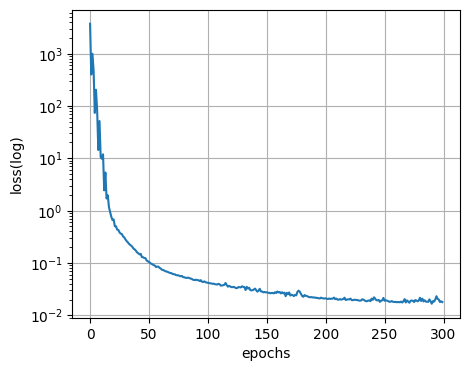

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(hist.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss(log)')
plt.yscale('log')
plt.grid()
plt.show()

In [ ]:
predict_train = model.predict(x_train)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


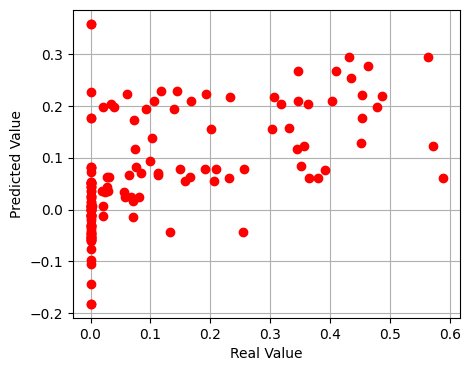

In [ ]:
plt.figure(figsize=(5,4))

plt.plot(y_train, predict_train, 'ro', label='train_set')

plt.xlabel('Real Value')
plt.ylabel('Predicted Value')

plt.grid()
plt.show()

In [ ]:
predict_test = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


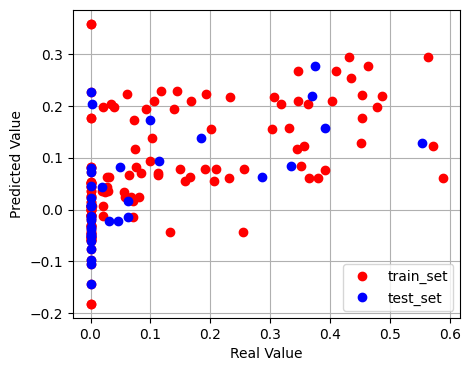

In [ ]:
plt.figure(figsize=(5,4))

plt.plot(y_train, predict_train, 'ro', label='train_set')
plt.plot(y_test, predict_test, 'bo', label='test_set')

plt.xlabel('Real Value')
plt.ylabel('Predicted Value')
plt.legend(loc='best')
plt.grid()

plt.show()

####### 이후는 랜덤포레스트

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=None)
rf_model.fit(x_train, y_train.ravel())

RandomForestRegressor()

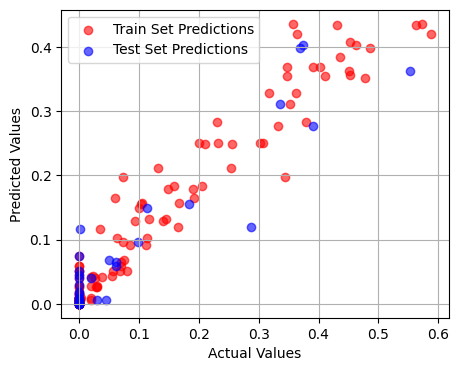

In [ ]:
predict_train_rf = rf_model.predict(x_train)
predict_test_rf = rf_model.predict(x_test)

plt.figure(figsize=(5,4))

plt.scatter(y_train, predict_train_rf, color='red', label='Train Set Predictions', alpha=0.6)
plt.scatter(y_test, predict_test_rf, color='blue', label='Test Set Predictions', alpha=0.6)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

####### 미국환경보호청(EPA)에 등록된 유기용제 5천여개를 Smiles 변환과 Descriptor 계산후 추출성능 추론 가능

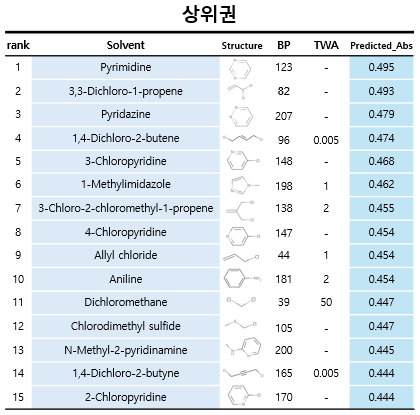